# M4A5 - Fundamentos de Modelos Multimodais

Na prática de hoje vamos usar o modelo [CLIP](https://openai.com/index/clip/) da OpenAI.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Utilizar o modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-gvhew12i
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-gvhew12i
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=1760ca77649a1d0df1807bc3aa4dadbeaf1200a9827593d165ac0987f9b1af39
  Stored in directory: /tmp/pip-ephem-wheel-cache-q1dh1t27/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import torch
import clip
import matplotlib.pyplot as plt
from PIL import Image

## Utilizar o Modelo

Para isso iremos instanciar o modelo do CLIP e utilizar com texto e imagens.

[' a street', 'a car', 'a bus']
Probabilidades imagem vs. textos: [54.21% de " a street", 33.69% de "a car", 12.10% de "a bus"]


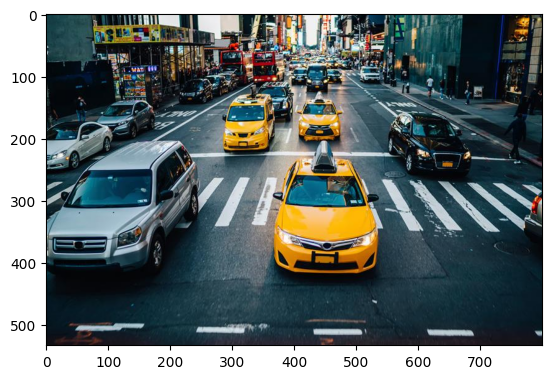

In [10]:
# Path para a imagem.
#path_image = "/content/rio.jpeg"
#path_image = "/content/dog.jpeg"
path_image = "/content/street.jpeg"

# Textos para avaliar.
#texts = ["a statue", "the moutains", "the beach"]
#texts = ["a cat", "a dog", "a diagram"]
texts = [" a street", "a car", "a bus"]

# Define o dispositivo a carregar o modelo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carrega o modelo com o backbone do ViT-B/32.
model, preprocess = clip.load("ViT-B/32", device=device)


# Processa a imagem.
image = preprocess(Image.open(path_image)).unsqueeze(0).to(device)

# Processa o texto.
text = clip.tokenize(texts).to(device)

# Roda inferências.
with torch.no_grad():
    _ = model.encode_image(image) # Encoda imagem.
    _ = model.encode_text(text) # Encoda o texto.

    logits_per_image, logits_per_text = model(image, text) # Computa similaridade entre imagem e textos.
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0] # Retorna probabilidades.

formated_probs_str = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(list(probs), texts)) + ']'

plt.imshow(Image.open(path_image))
print(texts)
print("Probabilidades imagem vs. textos:", formated_probs_str)

[' a street', 'a car', 'a bus']
Probabilidades imagem vs. textos: [7.59% de " a street", 27.28% de "a car", 65.13% de "a bus"]


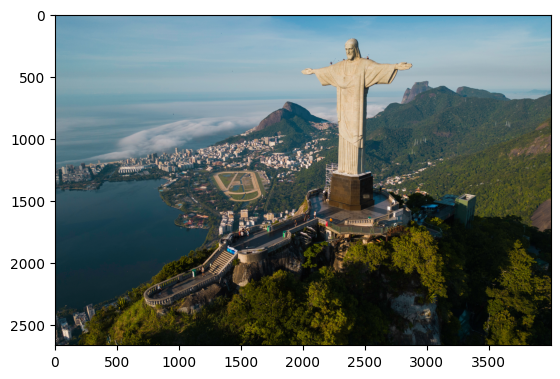

In [ ]:
# Path para a imagem.
#path_image = "/content/rio.jpeg"
#path_image = "/content/dog.jpeg"
parh_image = "/content/street.jpeg"

# Textos para avaliar.
#texts = ["a statue", "the moutains", "the beach"]
#texts = ["a cat", "a dog", "a diagram"]
texts = [" a street", "a car", "a bus"]

# Define o dispositivo a carregar o modelo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carrega o modelo com o backbone do ViT-B/32.
model, preprocess = clip.load("ViT-B/32", device=device)


# Processa a imagem.
image = preprocess(Image.open(path_image)).unsqueeze(0).to(device)

# Processa o texto.
text = clip.tokenize(texts).to(device)

# Roda inferências.
with torch.no_grad():
    _ = model.encode_image(image) # Encoda imagem.
    _ = model.encode_text(text) # Encoda o texto.

    logits_per_image, logits_per_text = model(image, text) # Computa similaridade entre imagem e textos.
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0] # Retorna probabilidades.

formated_probs_str = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(list(probs), texts)) + ']'

plt.imshow(Image.open(path_image))
print(texts)
print("Probabilidades imagem vs. textos:", formated_probs_str)

[' a street', 'a car', 'a bus']
Probabilidades imagem vs. textos: [7.59% de " a street", 27.28% de "a car", 65.13% de "a bus"]


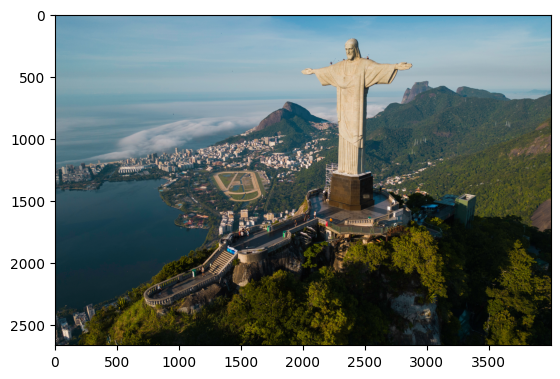

In [ ]:
# Path para a imagem.
#path_image = "/content/rio.jpeg"
#path_image = "/content/dog.jpeg"
parh_image = "/content/street.jpeg"

# Textos para avaliar.
#texts = ["a statue", "the moutains", "the beach"]
#texts = ["a cat", "a dog", "a diagram"]
texts = [" a street", "a car", "a bus"]

# Define o dispositivo a carregar o modelo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carrega o modelo com o backbone do ViT-B/32.
model, preprocess = clip.load("ViT-B/32", device=device)


# Processa a imagem.
image = preprocess(Image.open(path_image)).unsqueeze(0).to(device)

# Processa o texto.
text = clip.tokenize(texts).to(device)

# Roda inferências.
with torch.no_grad():
    _ = model.encode_image(image) # Encoda imagem.
    _ = model.encode_text(text) # Encoda o texto.

    logits_per_image, logits_per_text = model(image, text) # Computa similaridade entre imagem e textos.
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0] # Retorna probabilidades.

formated_probs_str = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(list(probs), texts)) + ']'

plt.imshow(Image.open(path_image))
print(texts)
print("Probabilidades imagem vs. textos:", formated_probs_str)

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/openai/CLIP
- https://openai.com/index/clip/
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente utilizar outros dados imagens e textos.
- [ ] Tente utilizar outro modelo base do CLIP. Details on https://github.com/openai/CLIP/blob/main/model-card.md#model-versions .